# 2D Quasi-Geostrophic model — tutorial

How to drive the integrator in `QG_2D.py`: run it with different parameter
settings, access derived fields (streamfunction, velocity), and visualize
snapshots and bulk diagnostics.

The prognostic variable is the relative vorticity $q$ on a doubly-periodic
$N\times N$ grid; the model solves

$$\frac{\partial q}{\partial t} + J(\psi,q) + \beta\,\frac{\partial\psi}{\partial x}
   = F - \mu\,q - \nu(-\nabla^2)^p q .$$

Make sure `QG_2D.py` is in the same directory as this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

from QG_2D import QG2D
from visualization import plot_snapshot, animate

## 1. A single run with the default forced–dissipative settings

`run(...)` integrates the model and returns an `xarray.Dataset` with dims
`(time, y, x)`; the model settings are stored in `ds.attrs`, and passing
`path=...` also writes a netCDF file.

In [10]:
m = QG2D(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)

if os.path.exists("qg_runs/qg_default.nc"):
    ds = m.load("qg_runs/qg_default.nc")
else:
    q0 = m.random_ic(seed=0, amp=2.0)        # smooth random initial vorticity
    ds = m.run(q0, tf=60, dt=0.01,           # integrate 60 time units, step 0.01
               spinup=40,                    # discard 40 units of spin-up first
               store_every=20,               # keep every 20th step
               path="qg_runs/qg_default.nc")         # also save to netCDF

ds

<xarray.Dataset>
Dimensions:  (time: 301, y: 64, x: 64)
Coordinates:
  * time     (time) float64 0.0 0.2 0.4 0.6 0.8 1.0 ... 59.2 59.4 59.6 59.8 60.0
  * y        (y) float64 0.0 0.09817 0.1963 0.2945 ... 5.89 5.989 6.087 6.185
  * x        (x) float64 0.0 0.09817 0.1963 0.2945 ... 5.89 5.989 6.087 6.185
Data variables:
    q        (time, y, x) float64 5.546 5.268 4.747 3.972 ... 7.948 8.466 8.394
Attributes:
    N:        64
    L:        6.283185307179586
    beta:     0.0
    mu:       0.1
    nu:       0.001
    p:        2
    A:        4.0
    k_f:      4

Snapshot and animation of vorticity

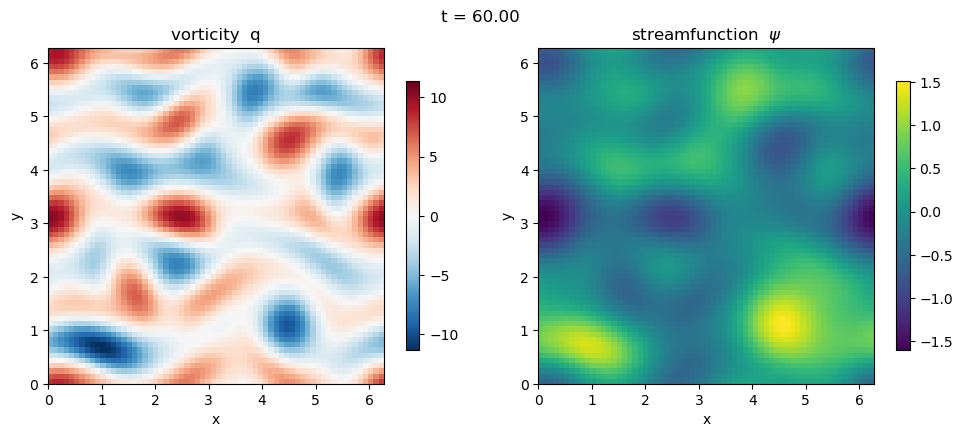

In [11]:
# last time step
plot_snapshot(ds)

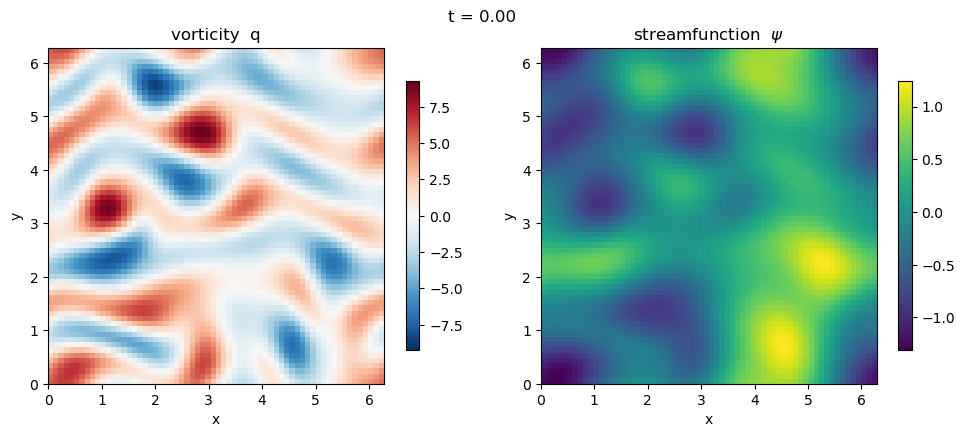

In [12]:
# first time step (after spinup)
plot_snapshot(ds, t_index=0, savepath='plots/snap.png')

In [14]:
# save animation as gif
if not os.path.exists("./plots/animation.gif"):
    animate(ds, savepath='./plots/animation.gif', fps=10)

Also plot stationary forcing (stationary Kolmogorov forcing)

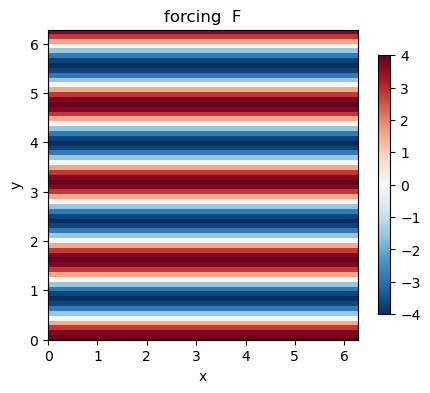

In [6]:
m = QG2D(N=64, A=4.0, k_f=4)          # forcing is fixed at construction

F = np.real(np.fft.ifft2(m.F_hat))   # the stationary forcing field, shape (N, N)
# equivalently: F = m.A * np.cos(m.k_f * m.Y)

extent = [0, m.L, 0, m.L]
fmax = np.abs(F).max()
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(F.T, cmap="RdBu_r", origin="lower", extent=extent, vmin=-fmax, vmax=fmax)
ax.set_title("forcing  F")
ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 2. Bulk diagnostics

Energy $E=\tfrac12\langle|\mathbf{u}|^2\rangle$ and enstrophy
$Z=\tfrac12\langle q^2\rangle$ over the stored trajectory.

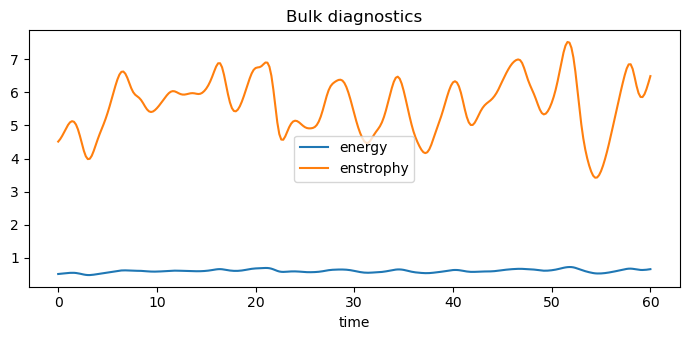

In [7]:
energy = np.array([m.energy(q) for q in ds.q.values])
enstrophy = np.array([m.enstrophy(q) for q in ds.q.values])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ds.time, energy, label="energy")
ax.plot(ds.time, enstrophy, label="enstrophy")
ax.set_xlabel("time")
ax.legend()
ax.set_title("Bulk diagnostics")
fig.tight_layout()
plt.show()

## 3. Parameter sweep: the planetary vorticity gradient $\beta$

Larger $\beta$ drives the flow from isotropic turbulence toward zonal (banded)
structure — Rossby waves and jets.

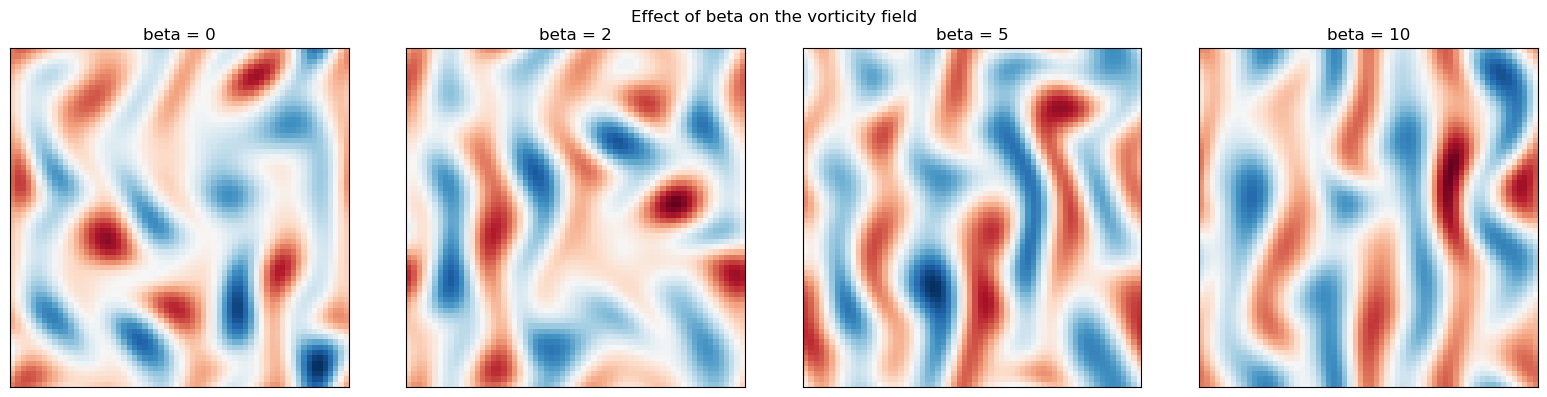

In [19]:
settings = {
    "beta = 0":   dict(beta=0.0),
    "beta = 2":  dict(beta=2.0),
    "beta = 5":  dict(beta=5.0),
    "beta = 10":  dict(beta=10.0),
}

os.makedirs("qg_runs", exist_ok=True)

fig, axes = plt.subplots(1, len(settings), figsize=(4 * len(settings), 4))
for ax, (label, override) in zip(axes, settings.items()):
    path = os.path.join("qg_runs", f"qg_beta_{override['beta']}.nc")
    model = QG2D(N=64, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4, **override)

    if os.path.exists(path):
        run = model.load(path)                        # reuse the saved simulation
    else:
        run = model.run(model.random_ic(seed=0, amp=2.0),
                        tf=40, dt=0.008, spinup=40, store_every=50,
                        path=path)                    # compute and cache

    field = run.q.isel(time=-1).values
    vmax = np.abs(field).max()
    ax.imshow(field, cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

    # also save animation
    if not os.path.exists(f"./plots/animation_beta_{override['beta']}.gif"):
        animate(run, savepath=f"./plots/animation_beta_{override['beta']}.gif", fps=10)

fig.suptitle("Effect of beta on the vorticity field")
fig.tight_layout()
plt.show()

## 4. Other knobs worth playing with

```python
m = QG2D(k_f=6)        # forcing wavenumber: smaller eddies
m = QG2D(A=8.0)        # stronger forcing: more energetic / turbulent
m = QG2D(mu=0.02)      # weaker drag: energy accumulates at large scales
m = QG2D(nu=5e-4, p=2) # weaker hyperviscosity: sharper small-scale features
m = QG2D(N=128)        # higher resolution (slower; may need smaller dt)
```

Reload a saved run later with:

```python
import xarray as xr
ds = xr.open_dataset("qg_default.nc")   # settings are in ds.attrs
```